### Modelos de mezclas para ajuste de TrendReturns

#### Modelos de Mezclas Gaussianas
- Libreria adecuada: scikitlearn.mixture.GaussianMixture
- Ajusta parámetros de n distribuciones gaussianas para ajustar una distribución de datos empíricos.

##### Testeo con datos sintéticos.
- Preprocesamiento de datos - Filtro datos(+,-), Normalización 
- 

In [20]:
import numpy as np 
from sklearn.mixture import GaussianMixture

# Datos de ejemplo
data = np.random.random(100).reshape(-1, 1)

# Definir el modelo de mezcla
gmm = GaussianMixture(n_components=3, max_iter=100, random_state=42)

# Ajustar el modelo a los datos
gmm.fit(data)

# Obtener los parámetros ajustados
weights = gmm.weights_
means = gmm.means_
covariances = gmm.covariances_

print("weights:", weights, "\nmeans:", means, "\ncovariances:", covariances)




weights: [0.24360694 0.41818506 0.338208  ] 
means: [[0.86412659]
 [0.55568934]
 [0.22893768]] 
covariances: [[[0.00861825]]

 [[0.01513207]]

 [[0.01617261]]]


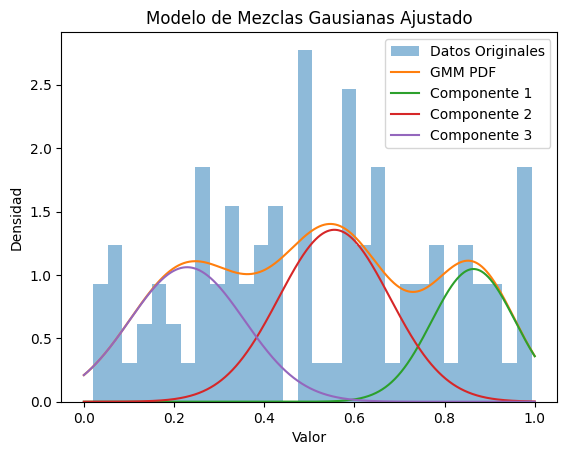

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generar una gama de valores x para graficar las curvas
x = np.linspace(0, 1, 1000).reshape(-1, 1)

# Calcular las densidades de probabilidad ajustadas
pdf = np.exp(gmm.score_samples(x))

# Graficar los datos originales
plt.hist(data, bins=30, density=True, alpha=0.5, label='Datos Originales')

# Graficar la densidad de probabilidad ajustada
plt.plot(x, pdf, label='GMM PDF')

# Visualizar cada componente de la mezcla
for i in range(gmm.n_components):
    pdf_i = weights[i] * (1 / np.sqrt(2 * np.pi * covariances[i])) * np.exp(-0.5 * ((x - means[i])**2) / covariances[i])
    plt.plot(x, pdf_i, label=f'Componente {i+1}')

plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.title('Modelo de Mezclas Gausianas Ajustado')
plt.legend()
plt.show()


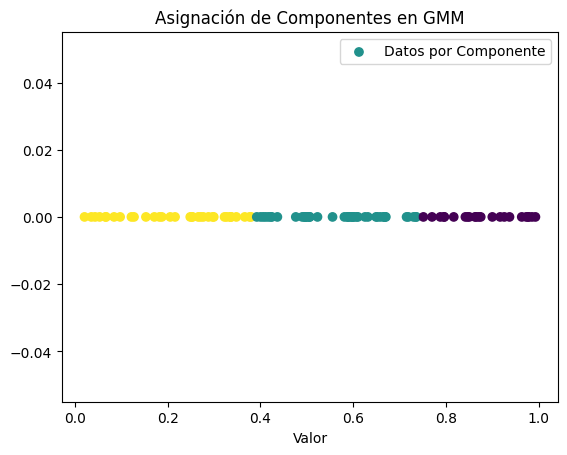

In [22]:
# Predecir la etiqueta de la mezcla para cada dato
labels = gmm.predict(data)

# Graficar los datos coloreados por su componente de mezcla
plt.scatter(data, np.zeros_like(data), c=labels, cmap='viridis', label='Datos por Componente')
plt.xlabel('Valor')
plt.title('Asignación de Componentes en GMM')
plt.legend()
plt.show()


#### Algoritmo E-M (Expectation - Maximization)

p: nan lambda: nan alpha: nan


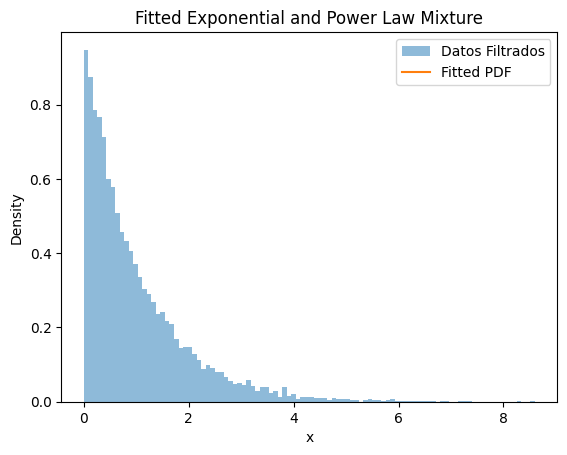

In [27]:
import numpy as np
from scipy.stats import expon, rv_continuous
from scipy.special import logsumexp

# Definir la distribución de ley de potencias personalizada
class power_law_gen(rv_continuous):
    def _pdf(self, x, alpha):
        return (alpha - 1) * x**(-alpha)

power_law = power_law_gen(a=1e-3, name='power_law')

# Definir el algoritmo EM
def em_algorithm(data, max_iter=10, tol=.002):
    # Inicialización de parámetros
    lam = 1.0
    alpha = 2.0
    p = 0.5
    log_likelihood = []

    for _ in range(max_iter):
        # E-step
        resp_exp = p * expon.pdf(data, scale=1/lam)
        resp_pl = (1 - p) * power_law.pdf(data, alpha)
        resp_sum = resp_exp + resp_pl
        
        gamma_exp = resp_exp / resp_sum
        gamma_pl = resp_pl / resp_sum

        # M-step
        p_new = np.mean(gamma_exp)
        lam_new = np.sum(gamma_exp) / np.sum(gamma_exp * data)
        alpha_new = 1 + np.sum(gamma_pl) / np.sum(gamma_pl * np.log(data))

        # Calcular la log-verosimilitud
        ll = np.sum(np.log(resp_sum)+ 1e-10)
        log_likelihood.append(ll)

        # Comprobar la convergencia
        if len(log_likelihood) > 1 and abs(log_likelihood[-1] - log_likelihood[-2]) < tol:
            break

        p, lam, alpha = p_new, lam_new, alpha_new

    return p, lam, alpha, log_likelihood

# Datos de ejemplo
data = np.random.exponential(scale=1.0, size=10000)
data = data[data>0]

# Ejecutar el algoritmo EM
p_fit, lam_fit, alpha_fit, log_likelihood = em_algorithm(data)

print("p:", p_fit, "lambda:", lam_fit, "alpha:", alpha_fit)

# Visualizar la distribución ajustada
import matplotlib.pyplot as plt

x = np.linspace(0.01, 5, 1000)
pdf_fitted = p_fit * expon.pdf(x, scale=1/lam_fit) + (1 - p_fit) * power_law.pdf(x, alpha_fit)

plt.hist(data, bins=100, density=True, alpha=0.5, label='Datos Filtrados')
plt.plot(x, pdf_fitted, label='Fitted PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Fitted Exponential and Power Law Mixture')
plt.legend()
plt.show()


p: nan lambda: nan alpha: nan


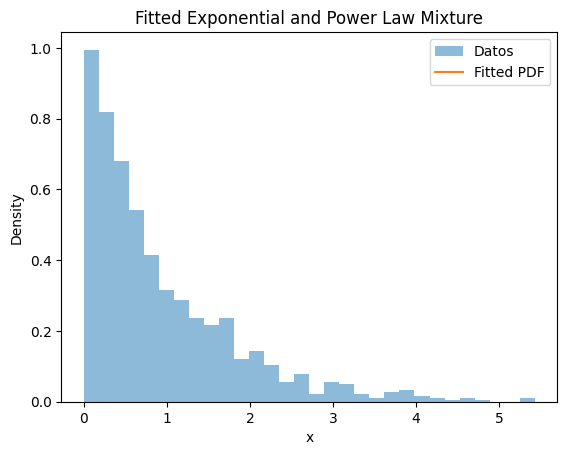

In [29]:
import numpy as np
from scipy.stats import expon, rv_continuous
import matplotlib.pyplot as plt

# Definir la distribución de ley de potencias personalizada
class power_law_gen(rv_continuous):
    def _pdf(self, x, alpha):
        return (alpha - 1) * x**(-alpha)

power_law = power_law_gen(a=1e-3, name='power_law')

# Definir el algoritmo EM
def em_algorithm(data, max_iter=100, tol=1e-6):
    # Inicialización de parámetros
    lam = 2
    alpha = 3
    p = 0.7
    log_likelihood = []

    for _ in range(max_iter):
        try:
            # E-step
            resp_exp = p * expon.pdf(data, scale=1/lam)
            resp_pl = (1 - p) * power_law.pdf(data, alpha)
            resp_sum = resp_exp + resp_pl
            
            # Prevenir divisiones por cero
            gamma_exp = np.where(resp_sum == 0, 0, resp_exp / resp_sum)
            gamma_pl = np.where(resp_sum == 0, 0, resp_pl / resp_sum)

            # M-step
            p_new = np.mean(gamma_exp)
            lam_new = np.sum(gamma_exp) / (np.sum(gamma_exp * data) + 1e-10)
            alpha_new = 1 + np.sum(gamma_pl) / (np.sum(gamma_pl * np.log(data)) + 1e-10)

            # Calcular la log-verosimilitud
            ll = np.sum(np.log(resp_sum + 1e-10))
            log_likelihood.append(ll)

            # Comprobar la convergencia
            if len(log_likelihood) > 1 and abs(log_likelihood[-1] - log_likelihood[-2]) < tol:
                break

            p, lam, alpha = p_new, lam_new, alpha_new
        except Exception as e:
            print(f"Error en la iteración: {e}")
            break

    return p, lam, alpha, log_likelihood

# Datos de ejemplo
data = np.random.exponential(scale=1.0, size=1000)
data = data[data > 0]

# Ejecutar el algoritmo EM
p_fit, lam_fit, alpha_fit, log_likelihood = em_algorithm(data)

print("p:", p_fit, "lambda:", lam_fit, "alpha:", alpha_fit)

# Visualizar la distribución ajustada
x = np.linspace(0.01, 5, 1000)
pdf_fitted = p_fit * expon.pdf(x, scale=1/lam_fit) + (1 - p_fit) * power_law.pdf(x, alpha_fit)

plt.hist(data, bins=30, density=True, alpha=0.5, label='Datos')
plt.plot(x, pdf_fitted, label='Fitted PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Fitted Exponential and Power Law Mixture')
plt.legend()
plt.show()


Media de los datos: 0.975290892203315
Desviación estándar de los datos: 0.9758560497300685
Iteración 0: p=0.1815761663533277, lambda=0.710255104319066, alpha=-0.30209970763911365, log-likelihood=714.7990724480676
Iteración 1: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 2: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 3: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 4: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 5: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 6: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 7: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 8: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 9: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 10: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 11: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 12: p=nan, lambda=nan, alpha=nan, log-likelihood=nan
Iteración 13: p=nan, lambda=nan, alpha=n

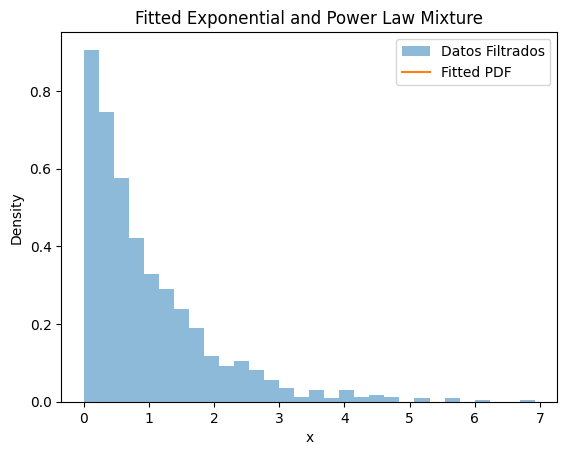

In [30]:
import numpy as np
from scipy.stats import expon, rv_continuous
import matplotlib.pyplot as plt

class power_law_gen(rv_continuous):
    def _pdf(self, x, alpha):
        return (alpha - 1) * x**(-alpha)

power_law = power_law_gen(a=1e-3, name='power_law')

def em_algorithm(data, max_iter=100, tol=1e-6):
    lam = 1.0
    alpha = 2.0
    p = 0.5
    log_likelihood = []

    for i in range(max_iter):
        try:
            resp_exp = p * expon.pdf(data, scale=1/lam)
            resp_pl = (1 - p) * power_law.pdf(data, alpha)
            resp_sum = resp_exp + resp_pl

            if np.any(resp_sum == 0):
                print(f'Iteración {i}: resp_sum contiene ceros, ajustando valores.')
                resp_sum[resp_sum == 0] = 1e-10

            gamma_exp = resp_exp / resp_sum
            gamma_pl = resp_pl / resp_sum

            p_new = np.mean(gamma_exp)
            lam_new = np.sum(gamma_exp) / (np.sum(gamma_exp * data) + 1e-10)
            alpha_new = 1 + np.sum(gamma_pl) / (np.sum(gamma_pl * np.log(data)) + 1e-10)

            ll = np.sum(np.log(resp_sum + 1e-10))
            log_likelihood.append(ll)

            print(f'Iteración {i}: p={p_new}, lambda={lam_new}, alpha={alpha_new}, log-likelihood={ll}')

            if len(log_likelihood) > 1 and abs(log_likelihood[-1] - log_likelihood[-2]) < tol:
                break

            p, lam, alpha = p_new, lam_new, alpha_new
        except Exception as e:
            print(f"Error en la iteración {i}: {e}")
            break

    return p, lam, alpha, log_likelihood

data = np.random.exponential(scale=1.0, size=1000)
data = data[data > 0]

mean_data = np.mean(data)
std_data = np.std(data)

print("Media de los datos:", mean_data)
print("Desviación estándar de los datos:", std_data)

p_fit, lam_fit, alpha_fit, log_likelihood = em_algorithm(data)

print("p:", p_fit, "lambda:", lam_fit, "alpha:", alpha_fit)

x = np.linspace(0.01, 5, 1000)
pdf_fitted = p_fit * expon.pdf(x, scale=1/lam_fit) + (1 - p_fit) * power_law.pdf(x, alpha_fit)

plt.hist(data, bins=30, density=True, alpha=0.5, label='Datos Filtrados')
plt.plot(x, pdf_fitted, label='Fitted PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Fitted Exponential and Power Law Mixture')
plt.legend()
plt.show()


Media de los datos: 0.9704013065596269
Desviación estándar de los datos: 0.9758018178989002
Iteración 0: p=0.18008238098130544, lambda=0.707123506588543, alpha=1.1, log-likelihood=711.1094889504543
Iteración 1: p=0.3228132176375816, lambda=0.8644779077955028, alpha=1.1, log-likelihood=-1437.7930146420554
Iteración 2: p=0.4978451024407775, lambda=0.9399029150108855, alpha=1.1, log-likelihood=-1301.4174104993413
Iteración 3: p=0.6552719614217639, lambda=0.9776578695585432, alpha=1.1, log-likelihood=-1174.1134161502673
Iteración 4: p=0.7688880137551726, lambda=0.9975098618182089, alpha=1.1, log-likelihood=-1084.3258962797277
Iteración 5: p=0.8421719486144351, lambda=1.0085955919739589, alpha=1.1, log-likelihood=-1032.0044247680933
Iteración 6: p=0.8879721591680079, lambda=1.0151499915891646, alpha=1.1, log-likelihood=-1004.1002906982758
Iteración 7: p=0.9169591657455597, lambda=1.0191908254871127, alpha=1.1, log-likelihood=-989.4574584113127
Iteración 8: p=0.9358902175043634, lambda=1.021

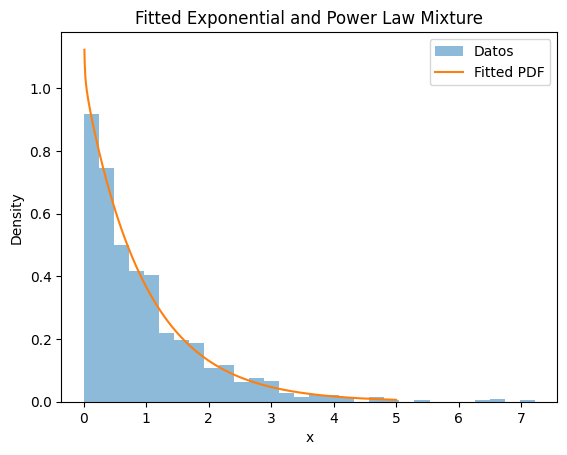

In [31]:
import numpy as np
from scipy.stats import expon, rv_continuous
import matplotlib.pyplot as plt

# Definir la distribución de ley de potencias personalizada
class power_law_gen(rv_continuous):
    def _pdf(self, x, alpha):
        return (alpha - 1) * x**(-alpha)

power_law = power_law_gen(a=1e-3, name='power_law')

# Definir el algoritmo EM
def em_algorithm(data, max_iter=100, tol=1e-6):
    lam = 1.0
    alpha = 2.0
    p = 0.5
    log_likelihood = []

    for i in range(max_iter):
        try:
            resp_exp = p * expon.pdf(data, scale=1/lam)
            resp_pl = (1 - p) * power_law.pdf(data, alpha)
            resp_sum = resp_exp + resp_pl

            if np.any(resp_sum == 0):
                print(f'Iteración {i}: resp_sum contiene ceros, ajustando valores.')
                resp_sum[resp_sum == 0] = 1e-10

            gamma_exp = resp_exp / resp_sum
            gamma_pl = resp_pl / resp_sum

            p_new = np.mean(gamma_exp)
            lam_new = np.sum(gamma_exp) / (np.sum(gamma_exp * data) + 1e-10)
            alpha_new = max(1 + np.sum(gamma_pl) / (np.sum(gamma_pl * np.log(data)) + 1e-10), 1.1)  # Evitar valores inválidos

            ll = np.sum(np.log(resp_sum + 1e-10))
            log_likelihood.append(ll)

            print(f'Iteración {i}: p={p_new}, lambda={lam_new}, alpha={alpha_new}, log-likelihood={ll}')

            if len(log_likelihood) > 1 and abs(log_likelihood[-1] - log_likelihood[-2]) < tol:
                break

            p, lam, alpha = p_new, lam_new, alpha_new
        except Exception as e:
            print(f"Error en la iteración {i}: {e}")
            break

    return p, lam, alpha, log_likelihood

# Datos de ejemplo
data = np.random.exponential(scale=1.0, size=1000)
data = data[data > 0]

mean_data = np.mean(data)
std_data = np.std(data)

print("Media de los datos:", mean_data)
print("Desviación estándar de los datos:", std_data)

p_fit, lam_fit, alpha_fit, log_likelihood = em_algorithm(data)

print("p:", p_fit, "lambda:", lam_fit, "alpha:", alpha_fit)

x = np.linspace(0.01, 5, 1000)
pdf_fitted = p_fit * expon.pdf(x, scale=1/lam_fit) + (1 - p_fit) * power_law.pdf(x, alpha_fit)

plt.hist(data, bins=30, density=True, alpha=0.5, label='Datos')
plt.plot(x, pdf_fitted, label='Fitted PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Fitted Exponential and Power Law Mixture')
plt.legend()
plt.show()


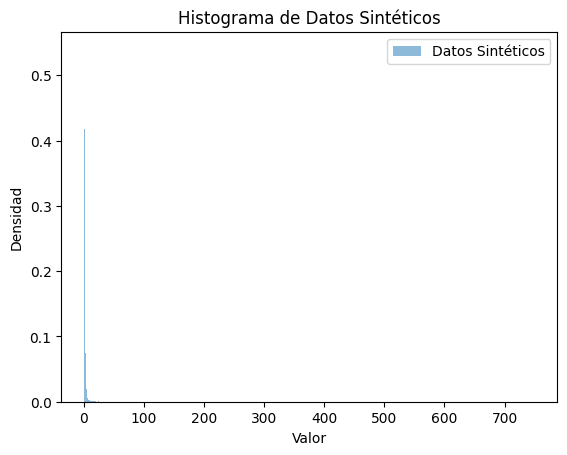

In [52]:
import numpy as np

def generate_synthetic_data(n_samples, p, lam, alpha, random_state=None):
    np.random.seed(random_state)
    # Generar etiquetas de la mezcla
    mixture_labels = np.random.binomial(1, p, n_samples)
    
    # Generar datos de la distribución exponencial
    exp_data = np.random.exponential(scale=1/lam, size=n_samples)
    
    # Generar datos de la ley de potencias
    pl_data = (np.random.uniform(size=n_samples) ** (-1 / (alpha - 1)))
    
    # Combinar los datos de acuerdo con las etiquetas de la mezcla
    data = mixture_labels * exp_data + (1 - mixture_labels) * pl_data
    
    return data

# Parámetros para los datos sintéticos
n_samples = 100000
p_true = 0.6  # Proporción de la distribución exponencial
lam_true = 1.5  # Parámetro de la distribución exponencial
alpha_true = 2.5  # Parámetro de la ley de potencias

# Generar los datos sintéticos
synthetic_data = generate_synthetic_data(n_samples, p_true, lam_true, alpha_true, random_state=42)
synthetic_data = synthetic_data[synthetic_data>0]

# Visualizar los datos sintéticos
plt.hist(synthetic_data, bins=1000, density=True, alpha=0.5, label='Datos Sintéticos')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.title('Histograma de Datos Sintéticos')
plt.legend()
plt.show()


Iteración 0: p=0.20172947784012807, lambda=0.6510741442211743, alpha=1.1, log-likelihood=16537.260389711806
Iteración 1: p=0.3617310230987955, lambda=0.7330435880185077, alpha=1.1, log-likelihood=-171335.65924087155
Iteración 2: p=0.5386842213352531, lambda=0.7710927558293592, alpha=1.1, log-likelihood=-156938.36410289875
Iteración 3: p=0.6822083406966647, lambda=0.7902042066435091, alpha=1.1, log-likelihood=-145002.57354226994
Iteración 4: p=0.77792047063663, lambda=0.7998375527846158, alpha=1.1, log-likelihood=-137656.39196796357
Iteración 5: p=0.8366616184706368, lambda=0.8041334724516213, alpha=1.1, log-likelihood=-133891.39387794104
Iteración 6: p=0.8721926751061408, lambda=0.8055657165788812, alpha=1.1, log-likelihood=-132116.44672850322
Iteración 7: p=0.8940176384562423, lambda=0.8056597338904812, alpha=1.1, log-likelihood=-131301.36552154762
Iteración 8: p=0.9077493156898934, lambda=0.8052451161060971, alpha=1.1, log-likelihood=-130927.43693937891
Iteración 9: p=0.9165928892894

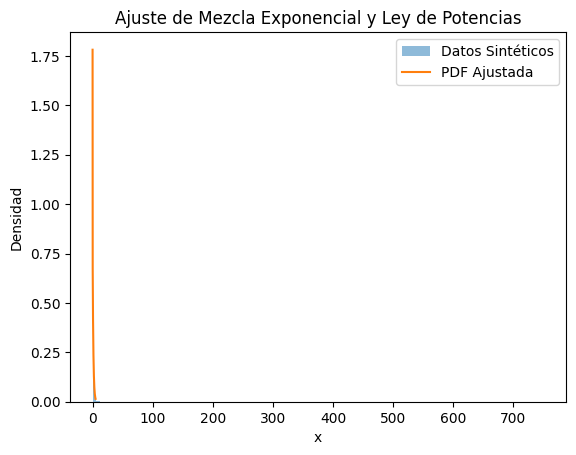

In [53]:
# Ejecutar el algoritmo EM en los datos sintéticos
p_fit, lam_fit, alpha_fit, log_likelihood = em_algorithm(synthetic_data)

# Mostrar los parámetros ajustados
print("p (ajustado):", p_fit)
print("lambda (ajustado):", lam_fit)
print("alpha (ajustado):", alpha_fit)

# Visualizar la distribución ajustada
x = np.linspace(0.01, 5, 1000)
pdf_fitted = p_fit * expon.pdf(x, scale=1/lam_fit) + (1 - p_fit) * power_law.pdf(x, alpha_fit)

plt.hist(synthetic_data, bins=1000, density=True, alpha=0.5, label='Datos Sintéticos')
plt.plot(x, pdf_fitted, label='PDF Ajustada')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.title('Ajuste de Mezcla Exponencial y Ley de Potencias')
plt.legend()
plt.show()
